In [159]:
import pandas as pd
import numpy as np
import torch
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Loading Dataset

In [348]:
df = pd.read_csv('./dataset/insurance.csv')

In [349]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Quality

In [350]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [351]:
df.duplicated().sum()

np.int64(1)

In [352]:
df = df.drop_duplicates()

# Encoding

In [353]:
ordinal_encoder = OrdinalEncoder(categories=[['female', 'male'], ['yes', 'no']])
df[['sex', 'smoker']] = ordinal_encoder.fit_transform(df[['sex', 'smoker']])

In [354]:
df = pd.get_dummies(df, columns=['region'], dtype=int)

In [355]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0.0,27.900,0,0.0,16884.92400,0,0,0,1
1,18,1.0,33.770,1,1.0,1725.55230,0,0,1,0
2,28,1.0,33.000,3,1.0,4449.46200,0,0,1,0
3,33,1.0,22.705,0,1.0,21984.47061,0,1,0,0
4,32,1.0,28.880,0,1.0,3866.85520,0,1,0,0


# Train Test Split

In [356]:
X = df.drop(columns=['charges'])
y = df[['charges']]

In [357]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 42
)

# Feature Scaling

In [358]:
# Creating scalers
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fitting training data
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)   

# Vanilla Stochastic Gradient Descent 

In [359]:
class LinearRegression:

    def __init__(self, lr=0.1, iterations=1000):

        self.lr = lr
        self.iterations = iterations
        self.loss_history = []

        # For visualizations
        self.training_history = {}
        self.weight_history = []


    def fit(self, X, y):

        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0

        self.loss_history = []
        self.weight_history = []

        no_improvement = 0

        for i in range(self.iterations):

            epoch_loss = 0

            # -----------------------
            # Stochastic Gradient Descent

            for sample in range(m):

                # Forward pass
                y_hat = np.dot(X[sample], self.weights) + self.bias

                loss = 1/2 * ((y_hat - y[sample])**2)

                epoch_loss += loss

                # Gradients
                dloss_dweights = X[sample] * (y_hat - y[sample])
                dloss_dbias = (y_hat - y[sample])

                # Parameter update
                self.weights -= self.lr * dloss_dweights
                self.bias -= self.lr * dloss_dbias

                # Save weights for visualization
                self.weight_history.append(self.weights.copy())

                # Save loss after EVERY update
                self.loss_history.append(loss)


    def predict(self, X):

        predictions = np.dot(X, self.weights) + self.bias

        return predictions

In [360]:
model_gd = LinearRegression(
    lr=0.1,
    iterations=200
)

In [361]:
model_gd.fit(X_train, y_train.ravel())

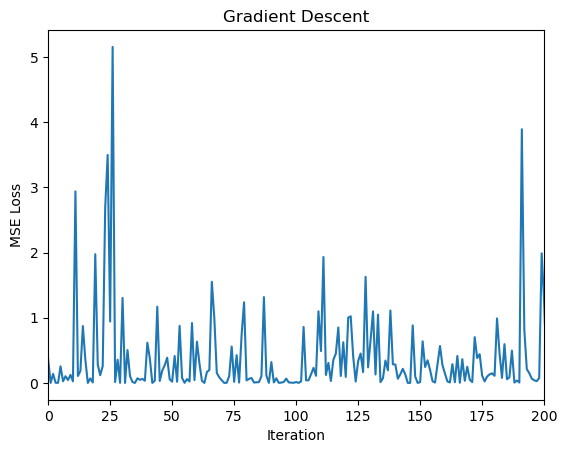

In [362]:
plt.plot(model_gd.loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent")

plt.xlim(0, 200)

plt.show()

In [363]:
preds = model_gd.predict(X_test)

In [364]:
mse = mean_squared_error(y_test, preds)
mse

0.5793108737024806

# GD with Momentum

In [365]:
class LinearRegression_Momentum:

    def __init__(self, lr=0.01, iterations=1000, beta=0.9):

        self.lr = lr
        self.iterations = iterations
        self.beta = beta

        self.V_t = 0
        self.V_b = 0

        self.loss_history = []

        # For visualizations
        self.training_history = {}
        self.weight_history = []


    def fit(self, X, y):

        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0

        self.V_t = np.zeros(n)
        self.V_b = 0

        self.loss_history = []
        self.weight_history = []

        no_improvement = 0

        for i in range(self.iterations):

            epoch_loss = 0

            # -----------------------
            # Stochastic Gradient Descent

            for sample in range(m):

                # Forward pass
                y_hat = np.dot(X[sample], self.weights) + self.bias

                loss = 1/2 * ((y_hat - y[sample])**2)

                epoch_loss += loss

                # Gradients
                dloss_dweights = X[sample] * (y_hat - y[sample])
                dloss_dbias = (y_hat - y[sample])

                # Momentum for weights
                self.V_t = (
                    self.beta * self.V_t
                    + (1 - self.beta) * dloss_dweights
                )

                # Momentum for bias
                self.V_b = (
                    self.beta * self.V_b
                    + (1 - self.beta) * dloss_dbias
                )

                # Parameter update
                self.weights -= self.lr * self.V_t
                self.bias -= self.lr * self.V_b

                # Save weights for visualization
                self.weight_history.append(self.weights.copy())

                # Save loss after EVERY update
                self.loss_history.append(loss)

    def predict(self, X):

        predictions = np.dot(X, self.weights) + self.bias

        return predictions

In [366]:
model_gd_momentum = LinearRegression_Momentum(
    lr=0.01,
    iterations=200,
    beta = 0.9
)

In [367]:
model_gd_momentum.fit(X_train,  y_train.ravel())

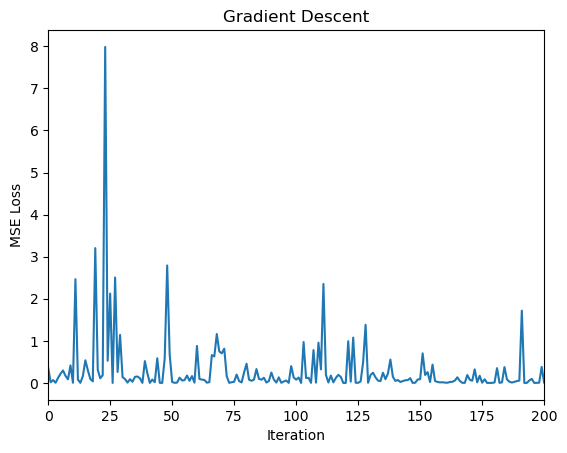

In [368]:
plt.plot(model_gd_momentum.loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent")

plt.xlim(0, 200)

plt.show()

In [369]:
preds = model_gd_momentum.predict(X_test)

In [370]:
mse = mean_squared_error(y_test, preds)
mse

0.24652218610771676

# Remarks

- We can see that loss fluctutaions in case of Vanilla SGD are high.
- But in case of SGD with momentum, loss fluctuations are low.
- Due to which weights updates are relatively smoother leading to lower testing MSE.

# Bias Correction

In [371]:
class LinearRegressionMoBias:

    def __init__(self, lr=0.01, iterations=1000, beta=0.9):
        self.lr = lr
        self.iterations = iterations
        self.beta = beta

        self.loss_history = []

        self.V_w = 0
        self.V_b = 0

    def fit(self, X, y):
        m, n = X.shape

        self.bias = 0
        self.weights = np.zeros(n)

        t = 0

        for epoch in range(self.iterations):

            for sample in range(m):

                # Prediction
                y_hat = np.dot(X[sample], self.weights) + self.bias

                # Error
                error = y_hat - y[sample]

                # Loss
                loss = error ** 2
                self.loss_history.append(loss)

                # Gradients
                dloss_dweights = np.dot(X[sample], error)
                dloss_dbias = error

                # Update time step
                t += 1

                # EWMA momentum for weights
                self.V_w = (
                    self.beta * self.V_w
                    + (1 - self.beta) * dloss_dweights
                )

                # EWMA momentum for bias
                self.V_b = (
                    self.beta * self.V_b
                    + (1 - self.beta) * dloss_dbias
                )

                # Bias correction
                V_w_corrected = self.V_w / (1 - self.beta ** t)
                V_b_corrected = self.V_b / (1 - self.beta ** t)

                # Parameter updates
                self.weights -= self.lr * V_w_corrected
                self.bias -= self.lr * V_b_corrected


    def predict(self, X):
        y_hat = np.dot(X, self.weights) + self.bias
        return y_hat

In [372]:
model_gd_momentum_bias = LinearRegressionMoBias(
    lr=0.01,
    iterations=200,
    beta = 0.9
)

In [373]:
model_gd_momentum_bias.fit(X_train, y_train.ravel())

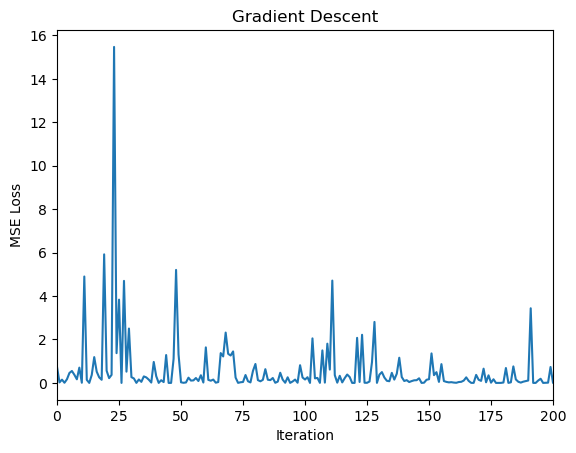

In [374]:
plt.plot(model_gd_momentum_bias.loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent")

plt.xlim(0, 200)

plt.show()

In [375]:
preds = model_gd_momentum.predict(X_test)

In [376]:
mse = mean_squared_error(y_test, preds)
mse

0.24652218610771676